<a href="https://colab.research.google.com/github/davidogm/RNAP/blob/main/BolsaRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicción de valores bursátiles usando Redes Neuronales Recurrentes**

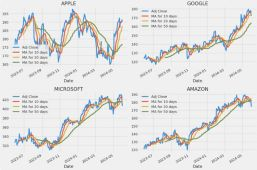


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM, GRU

In [3]:
# Configuración CUDA (si hay GPU disponible)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detectada: {len(gpus)}")
else:
    print("No se detectó GPU CUDA. Se entrenará en CPU.")

# Tickers del ejercicio (AAPL + 3 adicionales)
tickers = ['AAPL', 'EGLN.L', 'NUKL.DE', 'LSMC.DE']

No se detectó GPU CUDA. Se entrenará en CPU.


In [4]:
# Descarga de datos para todos los tickers
def download_data(ticker, start='2018-01-01', end='2025-05-13'):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        # yfinance puede devolver columnas multinivel según versión/configuración
        df.columns = df.columns.get_level_values(0)
    return df[['Close']].dropna()

data_by_ticker = {ticker: download_data(ticker) for ticker in tickers}
for ticker, df_ticker in data_by_ticker.items():
    print(f"{ticker}: {df_ticker.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

AAPL: (1850, 1)
EGLN.L: (1858, 1)
NUKL.DE: (575, 1)
LSMC.DE: (324, 1)


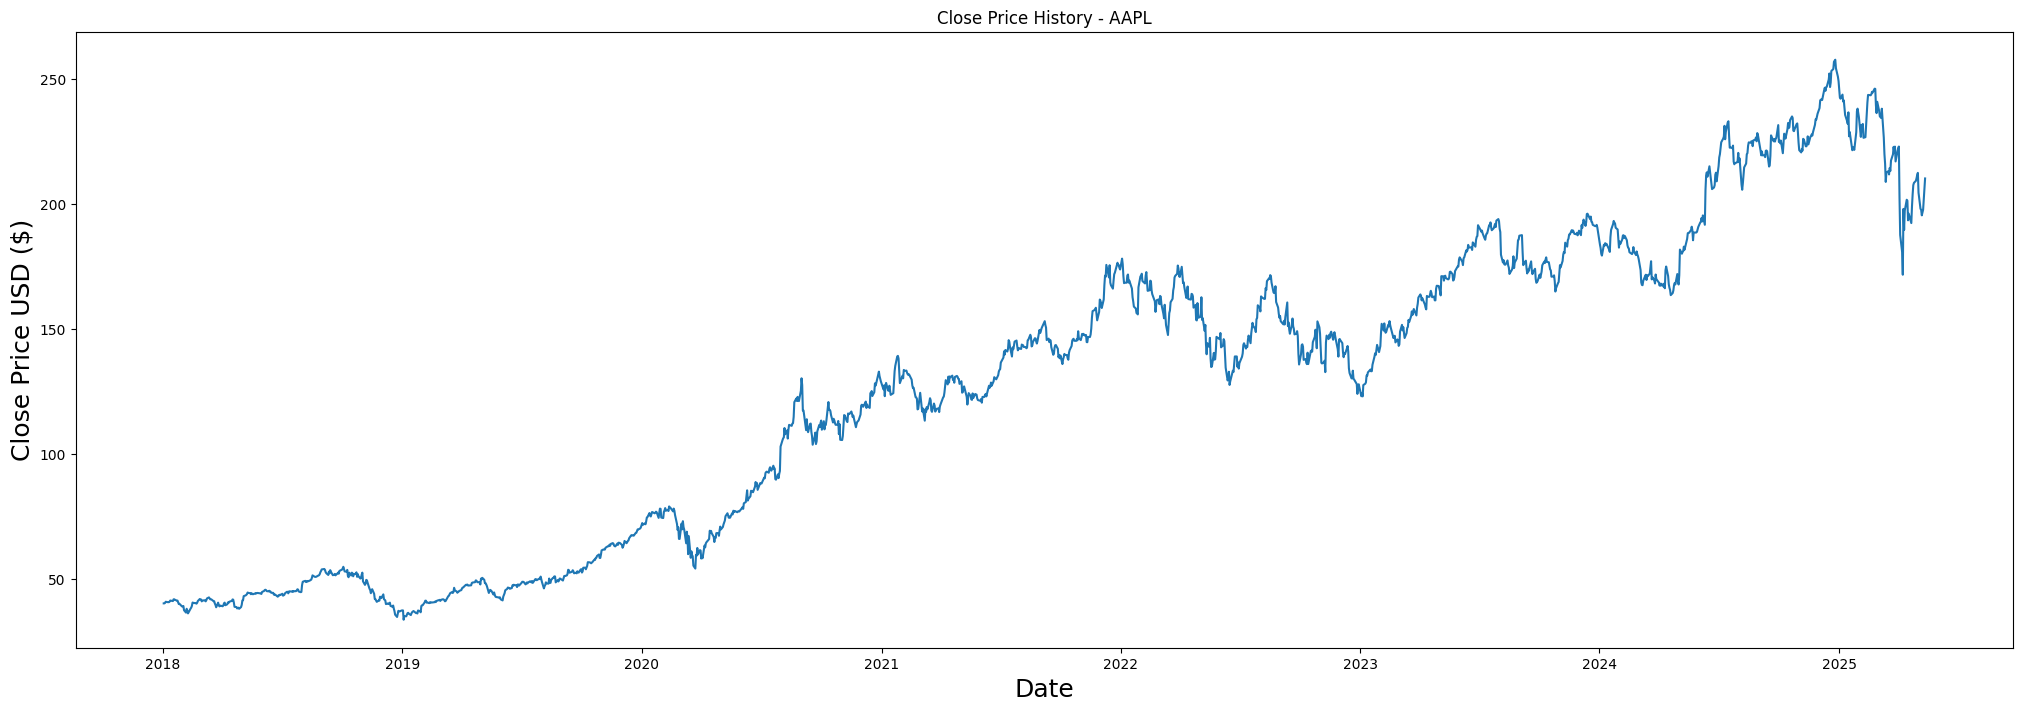

In [5]:
# mostramos gráfica para un ticker concreto (AAPL)
plt.figure(figsize=(25, 8))
plt.title('Close Price History - AAPL')
plt.plot(data_by_ticker['AAPL']['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [35]:
# Funciones reutilizables para preparar datos, entrenar y evaluar
def prepare_data(df_close, seq_len=60, train_ratio=0.95, test_points=60):
    # Se mantiene todo el histórico disponible en df_close; solo se reservan
    # los últimos test_points para evaluación final.
    dataset = df_close.values
    date_index = df_close.index
    training_data_len = len(dataset) - test_points
    training_data_len = max(training_data_len, seq_len + 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    train_data = scaled_data[:training_data_len, :]
    x_train, y_train = [], []
    for i in range(seq_len, len(train_data)):
        x_train.append(train_data[i-seq_len:i, 0])
        y_train.append(train_data[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    test_data = scaled_data[training_data_len - seq_len:, :]
    x_test = []
    y_test = dataset[training_data_len:, :]
    for i in range(seq_len, len(test_data)):
        x_test.append(test_data[i-seq_len:i, 0])

    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    return {
        'dataset': dataset,
        'date_index': date_index,
        'full_start': date_index[0],
        'full_end': date_index[-1],
        'train_start': date_index[0],
        'train_end': date_index[training_data_len - 1],
        'test_start': date_index[training_data_len],
        'test_end': date_index[-1],
        'training_data_len': training_data_len,
        'scaler': scaler,
        'x_train': x_train,
        'y_train': y_train,
        'x_test': x_test,
        'y_test': y_test,
    }

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(128, return_sequences=True, input_shape=input_shape))
    model.add(SimpleRNN(64, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def build_gru(input_shape):
    model = Sequential()
    model.add(GRU(128, return_sequences=True, input_shape=input_shape))
    model.add(GRU(64, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

def train_and_evaluate(model_builder, prepared_data, epochs=1, batch_size=1):
    model = model_builder((prepared_data['x_train'].shape[1], 1))
    model.fit(prepared_data['x_train'], prepared_data['y_train'], batch_size=batch_size, epochs=epochs, verbose=0)
    predictions = model.predict(prepared_data['x_test'], verbose=0)
    predictions = prepared_data['scaler'].inverse_transform(predictions)
    rmse = np.sqrt(np.mean((predictions - prepared_data['y_test']) ** 2))
    return model, predictions, rmse

In [36]:
# Preparación de datos para todos los tickers
prepared_by_ticker = {
    ticker: prepare_data(df_close, test_points=TEST_POINTS)
    for ticker, df_close in data_by_ticker.items()
}
for ticker, prep in prepared_by_ticker.items():
    print(
        f"{ticker}: full=[{prep['full_start'].date()} -> {prep['full_end'].date()}], "
        f"train=[{prep['train_start'].date()} -> {prep['train_end'].date()}], "
        f"test=[{prep['test_start'].date()} -> {prep['test_end'].date()}], "
        f"train_shape={prep['x_train'].shape}, test_shape={prep['x_test'].shape}"
    )

AAPL: full=[2018-01-02 -> 2025-05-12], train=[2018-01-02 -> 2025-02-13], test=[2025-02-14 -> 2025-05-12], train_shape=(1730, 60, 1), test_shape=(60, 60, 1)
EGLN.L: full=[2018-01-02 -> 2025-05-12], train=[2018-01-02 -> 2025-02-12], test=[2025-02-13 -> 2025-05-12], train_shape=(1738, 60, 1), test_shape=(60, 60, 1)
NUKL.DE: full=[2023-02-03 -> 2025-05-12], train=[2023-02-03 -> 2025-02-12], test=[2025-02-13 -> 2025-05-12], train_shape=(455, 60, 1), test_shape=(60, 60, 1)
LSMC.DE: full=[2024-01-29 -> 2025-05-12], train=[2024-01-29 -> 2025-02-12], test=[2025-02-13 -> 2025-05-12], train_shape=(204, 60, 1), test_shape=(60, 60, 1)


In [27]:
# Modelos a comparar
model_builders = {
    'RNN': build_rnn,
    'LSTM': build_lstm,
    'GRU': build_gru,
}

EPOCHS = 1  # se mantiene similar al notebook original
BATCH_SIZE = 1
TEST_POINTS = 60  # más posiciones de predicción
PLOT_CONTEXT_FACTOR = 3  # para que predicción sea 1/4 del gráfico (3:1)

In [29]:
# Entrenamiento y evaluación para todos los tickers y modelos
trained_models = {}
predictions_by_ticker_model = {}
rmse_rows = []

for ticker in tickers:
    prep = prepared_by_ticker[ticker]
    trained_models[ticker] = {}
    predictions_by_ticker_model[ticker] = {}
    print(f"\nTicker: {ticker}")

    for model_name, model_builder in model_builders.items():
        model, preds, rmse = train_and_evaluate(
            model_builder, prep, epochs=EPOCHS, batch_size=BATCH_SIZE
        )
        trained_models[ticker][model_name] = model
        predictions_by_ticker_model[ticker][model_name] = preds
        rmse_rows.append({'Ticker': ticker, 'Modelo': model_name, 'RMSE': float(rmse)})
        print(f"  {model_name} -> RMSE: {rmse:.4f}")


Ticker: AAPL


C:\Users\jordi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  RNN -> RMSE: 13.0413


C:\Users\jordi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM -> RMSE: 10.1340


...

  RNN -> RMSE: 2.7087


C:\Users\jordi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM -> RMSE: 3.1996


C:\Users\jordi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  GRU -> RMSE: 2.6053


In [30]:
# Tabla de resultados (RMSE)
rmse_df = pd.DataFrame(rmse_rows).sort_values(['Ticker', 'RMSE']).reset_index(drop=True)
rmse_df

,Ticker,Modelo,RMSE
0,AAPL,GRU,6.781136
1,AAPL,LSTM,10.134041
2,AAPL,RNN,13.041283
3,EGLN.L,GRU,0.770750
4,EGLN.L,LSTM,1.196616
5,EGLN.L,RNN,25.874114
6,LSMC.DE,GRU,2.605319
7,LSMC.DE,RNN,2.708747
8,LSMC.DE,LSTM,3.199620
9,NUKL.DE,GRU,1.437137


### Comparativa de modelos RNN, LSTM y GRU

In [31]:
# RMSE por ticker en formato pivote
rmse_pivot = rmse_df.pivot(index='Ticker', columns='Modelo', values='RMSE')
rmse_pivot

Modelo,GRU,LSTM,RNN
Ticker,,,
AAPL,6.781136,10.134041,13.041283
EGLN.L,0.770750,1.196616,25.874114
LSMC.DE,2.605319,3.199620,2.708747
NUKL.DE,1.437137,2.595010,1.529810


In [32]:
# Preparar marcos train/valid para los 4 tickers
plot_data = {}
for ticker in tickers:
    prep = prepared_by_ticker[ticker]
    data = data_by_ticker[ticker]

    train = data[:prep['training_data_len']].copy()
    valid = data[prep['training_data_len']:].copy()
    valid['Pred_RNN'] = predictions_by_ticker_model[ticker]['RNN']
    valid['Pred_LSTM'] = predictions_by_ticker_model[ticker]['LSTM']
    valid['Pred_GRU'] = predictions_by_ticker_model[ticker]['GRU']

    plot_data[ticker] = {'train': train, 'valid': valid}

plot_data['AAPL']['valid'].head()

Price,Close,Pred_RNN,Pred_LSTM,Pred_GRU
Date,,,,
2025-02-14,243.538544,225.070709,228.256577,239.117401
2025-02-18,243.409134,231.776810,230.741684,242.481003
2025-02-19,243.807373,228.821457,233.133194,243.108795
2025-02-20,244.763214,230.485519,235.185043,243.481445
2025-02-21,244.484436,230.890594,236.901245,244.258148


In [13]:
# Mejor modelo por ticker
best_models = rmse_df.loc[rmse_df.groupby('Ticker')['RMSE'].idxmin()].reset_index(drop=True)
best_models

,Ticker,Modelo,RMSE
0,AAPL,GRU,8.066685
1,EGLN.L,GRU,0.707475
2,LSMC.DE,LSTM,1.657051
3,NUKL.DE,GRU,1.305634


In [33]:
# Comprobación de tamaños para todos los tickers
for ticker in tickers:
    train = plot_data[ticker]['train']
    valid = plot_data[ticker]['valid']
    print(f"{ticker}: train={train.shape}, valid={valid.shape}")

AAPL: train=(1790, 1), valid=(60, 4)
EGLN.L: train=(1798, 1), valid=(60, 4)
NUKL.DE: train=(515, 1), valid=(60, 4)
LSMC.DE: train=(264, 1), valid=(60, 4)


In [25]:
# Últimas predicciones para los 4 tickers
for ticker in tickers:
    print(f"\n{ticker}")
    display(plot_data[ticker]['valid'][['Close', 'Pred_RNN', 'Pred_LSTM', 'Pred_GRU']].tail())


AAPL


Price,Close,Pred_RNN,Pred_LSTM,Pred_GRU
Date,,,,
2025-05-06,197.648544,206.974442,205.147934,214.550476
2025-05-07,195.398361,202.777039,202.331024,211.770340
2025-05-08,196.632996,199.675354,199.573151,209.477722
2025-05-09,197.668488,199.922806,197.706268,209.420578
2025-05-12,210.150497,200.218414,196.805939,210.220581



EGLN.L


Price,Close,Pred_RNN,Pred_LSTM,Pred_GRU
Date,,,,
2025-05-06,58.230000,54.735294,55.221123,56.209751
2025-05-07,58.000000,56.247772,55.460171,57.876106
2025-05-08,57.665001,57.767342,55.804901,58.496563
2025-05-09,57.639999,57.659416,56.096889,58.438358
2025-05-12,56.599998,57.056728,56.319534,58.351460



NUKL.DE


Price,Close,Pred_RNN,Pred_LSTM,Pred_GRU
Date,,,,
2025-05-06,27.230000,25.826336,26.728203,27.371655
2025-05-07,27.920000,26.512291,26.964350,27.456852
2025-05-08,28.495001,26.667505,27.218668,27.748789
2025-05-09,28.665001,28.108183,27.517859,28.181185
2025-05-12,29.615000,28.338045,27.824968,28.530725



LSMC.DE


Price,Close,Pred_RNN,Pred_LSTM,Pred_GRU
Date,,,,
2025-05-06,43.634998,44.233330,44.603645,43.201118
2025-05-07,43.154999,44.131557,45.025112,43.620983
2025-05-08,44.610001,43.703850,45.342804,43.698418
2025-05-09,44.744999,44.743580,45.687698,44.028694
2025-05-12,47.700001,45.326015,46.018570,44.375542


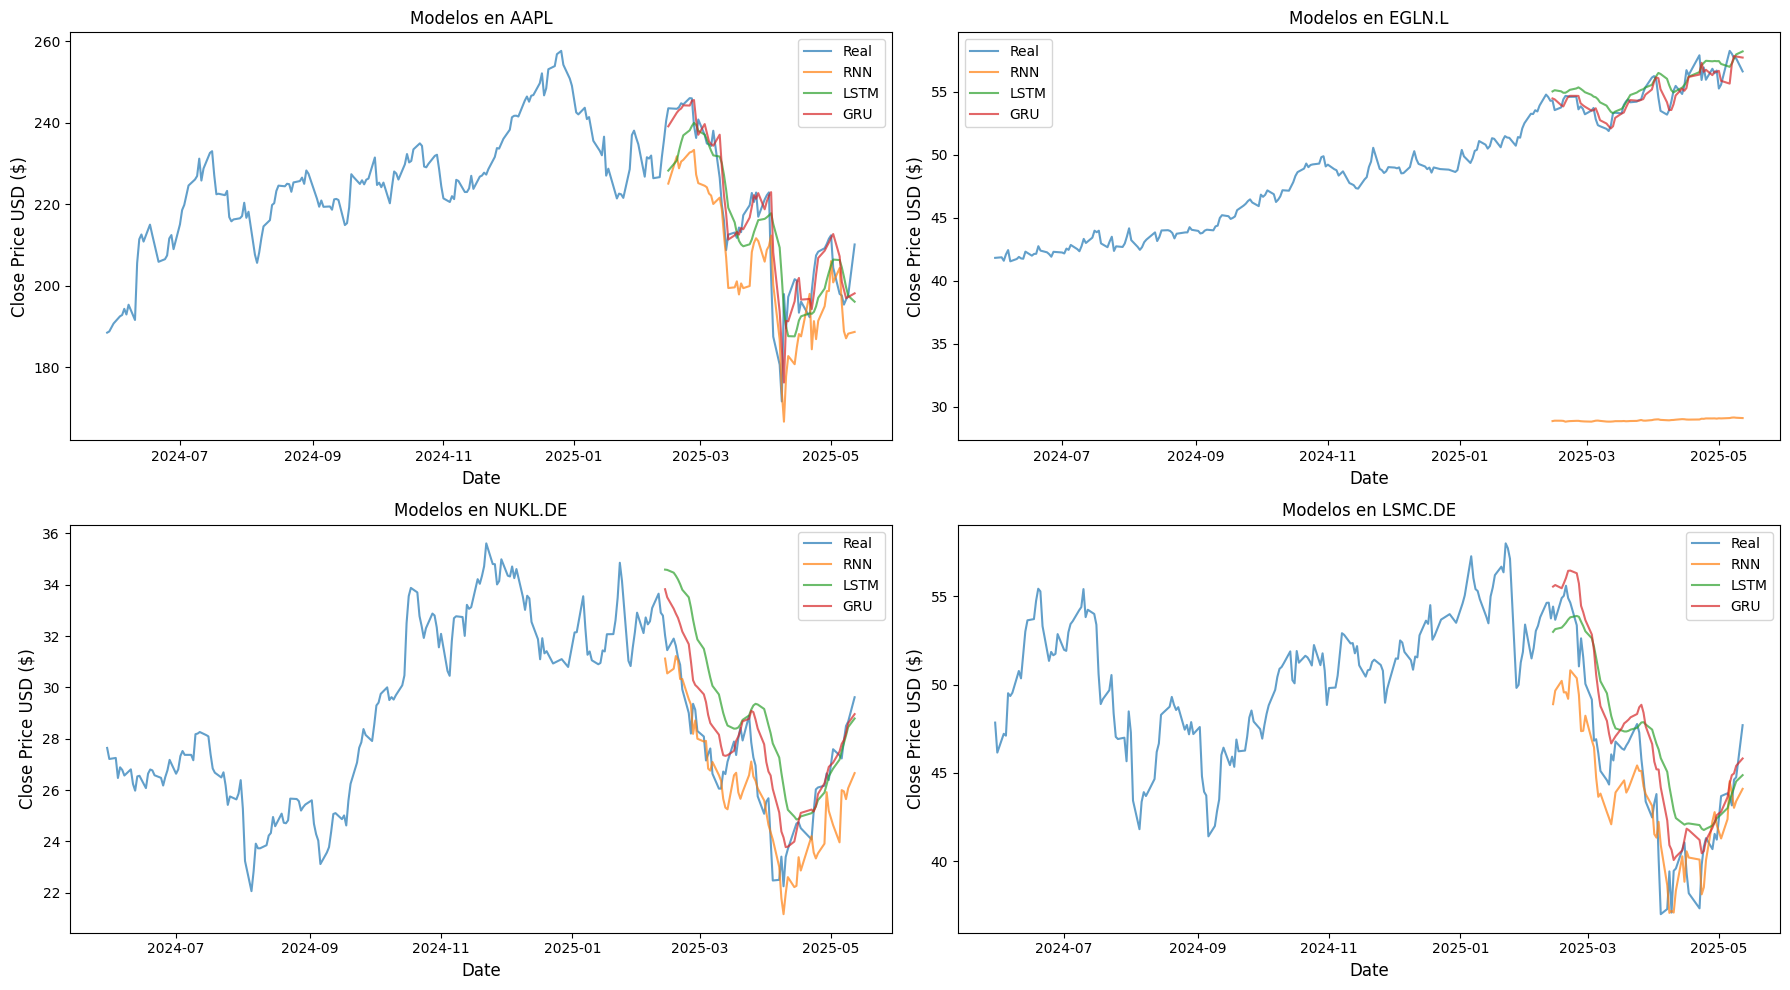

In [34]:
# Visualización final para las 4 compañías
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False)
axes = axes.flatten()

for ax, ticker in zip(axes, tickers):
    train = plot_data[ticker]['train']
    valid = plot_data[ticker]['valid']

    # Ventana final: contexto dinámico para que la predicción sea 1/4 del gráfico
    context_points = PLOT_CONTEXT_FACTOR * len(valid)
    train_tail = train.tail(context_points)
    window = pd.concat([train_tail, valid], axis=0)

    ax.set_title(f'Modelos en {ticker}')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Close Price USD ($)', fontsize=12)
    ax.plot(window.index, window['Close'], label='Real', alpha=0.7)
    ax.plot(valid.index, valid['Pred_RNN'], label='RNN', alpha=0.7)
    ax.plot(valid.index, valid['Pred_LSTM'], label='LSTM', alpha=0.7)
    ax.plot(valid.index, valid['Pred_GRU'], label='GRU', alpha=0.7)
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

# Ejercicios completados

1. Se han incluido tres acciones adicionales de Yahoo Finance: EGLN.L, NUKL.DE y LSMC.DE (además de AAPL).
2. Se han generado predicciones con tres arquitecturas (RNN, LSTM y GRU) y se ha calculado el RMSE para cada modelo y ticker.
3. Se han visualizado las predicciones de los tres modelos frente a los precios reales.
4. Todo el flujo se ha encapsulado en funciones para reutilización.
5. Se ha activado CUDA cuando hay GPU disponible para acelerar el entrenamiento.